<a href="https://colab.research.google.com/github/apirakqqqqq/Ge338-GEOGRAPHIC-DATA-SCIENCE/blob/main/Lab_2/Lab_2_6606614870_%E0%B8%AD%E0%B8%A0%E0%B8%B4%E0%B8%A3%E0%B8%B1%E0%B8%81%E0%B8%A9%E0%B9%8C_%E0%B8%9B%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%AA%E0%B8%B2%E0%B8%84%E0%B8%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas rasterio folium shapely matplotlib -q

import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


คำนวณและแสดงผล Spectal index

In [ ]:
import rasterio
import numpy as np
import folium
import matplotlib.pyplot as plt
from matplotlib import cm
from folium.raster_layers import ImageOverlay

# =======================
# 1. โหลดไฟล์
# =======================
file_early = "/content/drive/MyDrive/เลย/Loei_EarlyDry_2022.tif"
file_late  = "/content/drive/MyDrive/เลย/Loei_LateDry_2022.tif"

src_e = rasterio.open(file_early)
src_l = rasterio.open(file_late)

# =======================
# 2. อ่าน band
# =======================
ndvi_e = src_e.read(1)
ndmi_e = src_e.read(2)
ndwi_e = src_e.read(3)

ndvi_l = src_l.read(1)
ndmi_l = src_l.read(2)
ndwi_l = src_l.read(3)

# =======================
# 3. normalize + colormap
# =======================
def to_rgb(array):
    arr = np.nan_to_num(array)
    arr_norm = (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

    cmap = cm.viridis
    rgb = cmap(arr_norm)[:, :, :3]  # เอาเฉพาะ RGB
    rgb = (rgb * 255).astype(np.uint8)

    return rgb

# =======================
# 4. แปลงเป็น RGB
# =======================
ndvi_e_rgb = to_rgb(ndvi_e)
ndvi_l_rgb = to_rgb(ndvi_l)

ndmi_e_rgb = to_rgb(ndmi_e)
ndmi_l_rgb = to_rgb(ndmi_l)

ndwi_e_rgb = to_rgb(ndwi_e)
ndwi_l_rgb = to_rgb(ndwi_l)

# =======================
# 5. map
# =======================
bounds = [
    [src_e.bounds.bottom, src_e.bounds.left],
    [src_e.bounds.top, src_e.bounds.right]
]

m = folium.Map(location=[17.5, 101.7], zoom_start=8)

# =======================
# 6. layer
# =======================
ImageOverlay(ndvi_e_rgb, bounds=bounds, name='NDVI Early').add_to(m)
ImageOverlay(ndvi_l_rgb, bounds=bounds, name='NDVI Late').add_to(m)

ImageOverlay(ndmi_e_rgb, bounds=bounds, name='NDMI Early').add_to(m)
ImageOverlay(ndmi_l_rgb, bounds=bounds, name='NDMI Late').add_to(m)

ImageOverlay(ndwi_e_rgb, bounds=bounds, name='NDWI Early').add_to(m)
ImageOverlay(ndwi_l_rgb, bounds=bounds, name='NDWI Late').add_to(m)

# =======================
# 7. toggle
# =======================
folium.LayerControl().add_to(m)

m

Zonal statistics

In [ ]:
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import numpy as np

# =======================
# 1. โหลด shapefile
# =======================
shp = gpd.read_file("/content/drive/MyDrive/เลย/LU_LEI_2565.shp")

# =======================
# 2. โหลด raster 2 ช่วงเวลา
# =======================
file_early = "/content/drive/MyDrive/เลย/Loei_EarlyDry_2022.tif"
file_late  = "/content/drive/MyDrive/เลย/Loei_LateDry_2022.tif"

src_early = rasterio.open(file_early)
src_late  = rasterio.open(file_late)

# =======================
# 3. แก้ CRS
# =======================
shp = shp.to_crs(src_early.crs)

# =======================
# 4. อ่าน NDVI (band 1)
# =======================
ndvi_early = src_early.read(1)
ndvi_late  = src_late.read(1)

# =======================
# 5. คำนวณ change
# =======================
ndvi_change = ndvi_late - ndvi_early

# =======================
# 6. Zonal Statistics (เร็วขึ้น)
# =======================
stats_early = zonal_stats(
    shp.geometry,
    ndvi_early,
    affine=src_early.transform,
    stats=['mean'],
    nodata=-999
)

stats_late = zonal_stats(
    shp.geometry,
    ndvi_late,
    affine=src_early.transform,
    stats=['mean'],
    nodata=-999
)

stats_diff = zonal_stats(
    shp.geometry,
    ndvi_change,
    affine=src_early.transform,
    stats=['mean'],
    nodata=-999
)

# =======================
# 7. ใส่ค่า
# =======================
shp['NDVI_Early'] = [s['mean'] for s in stats_early]
shp['NDVI_Late']  = [s['mean'] for s in stats_late]
shp['NDVI_Change'] = [s['mean'] for s in stats_diff]

# =======================
# 8. แสดงผล (แก้ชื่อคอลัมน์แล้ว)
# =======================
print(shp[['LU_DES_TH','NDVI_Early','NDVI_Late','NDVI_Change']])

                       LU_DES_TH  NDVI_Early  NDVI_Late  NDVI_Change
0       เกษตรผสมผสาน/ไร่นาสวนผสม    0.189601   0.171482    -0.018119
1       เกษตรผสมผสาน/ไร่นาสวนผสม    0.374399   0.341119    -0.033280
2       เกษตรผสมผสาน/ไร่นาสวนผสม    0.202162   0.180378    -0.021784
3       เกษตรผสมผสาน/ไร่นาสวนผสม    0.163652   0.104168    -0.059484
4       เกษตรผสมผสาน/ไร่นาสวนผสม    0.372750   0.314888    -0.057862
...                          ...         ...        ...          ...
151484              คลองชลประทาน    0.247167   0.397713     0.150546
151485              คลองชลประทาน    0.221501   0.170055    -0.051446
151486              คลองชลประทาน    0.261413   0.235902    -0.025511
151487              คลองชลประทาน    0.261362   0.212165    -0.049197
151488              คลองชลประทาน    0.235543   0.175348    -0.060195

[151489 rows x 4 columns]


เปรียบเทียบ Composite 2 ช่วงเวลา

===== NDVI CHANGE SUMMARY =====
Mean Change: -0.017538127
Increase area (km²): 2969.0163
Decrease area (km²): 4215.8556
No change area (km²): 4018.1985


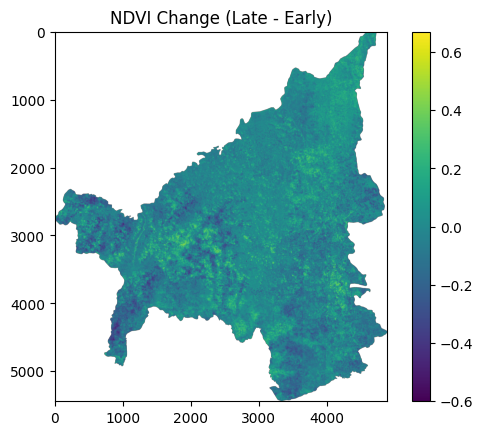

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# =======================
# 1. โหลดไฟล์
# =======================
file_early = "/content/drive/MyDrive/เลย/Loei_EarlyDry_2022.tif"
file_late  = "/content/drive/MyDrive/เลย/Loei_LateDry_2022.tif"

src1 = rasterio.open(file_early)
src2 = rasterio.open(file_late)

ndvi_early = src1.read(1)
ndvi_late  = src2.read(1)

# =======================
# 2. คำนวณการเปลี่ยนแปลง
# =======================
diff = ndvi_late - ndvi_early

# =======================
# 3. แสดงภาพ
# =======================
plt.figure()
plt.imshow(diff)
plt.title("NDVI Change (Late - Early)")
plt.colorbar()

# =======================
# 4. คำนวณพื้นที่เพิ่ม/ลด
# =======================
increase = diff > 0.05
decrease = diff < -0.05
no_change = (diff >= -0.05) & (diff <= 0.05)

# pixel area (30m)
pixel_area = 30 * 30 / 1e6  # km²

area_inc = np.sum(increase) * pixel_area
area_dec = np.sum(decrease) * pixel_area
area_no  = np.sum(no_change) * pixel_area

# =======================
# 5. ค่าเฉลี่ยการเปลี่ยนแปลง
# =======================
mean_change = np.nanmean(diff)

# =======================
# 6. แสดงผลลัพธ์
# =======================
print("===== NDVI CHANGE SUMMARY =====")
print("Mean Change:", mean_change)
print("Increase area (km²):", area_inc)
print("Decrease area (km²):", area_dec)
print("No change area (km²):", area_no)

วิเคราะห์ความสัมพันธ์ระหว่าง Index 2 ตัว

=== Early Dry Season ===
          NDVI      NDMI
NDVI  1.000000  0.663524
NDMI  0.663524  1.000000

=== Late Dry Season ===
          NDVI      NDMI
NDVI  1.000000  0.716385
NDMI  0.716385  1.000000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


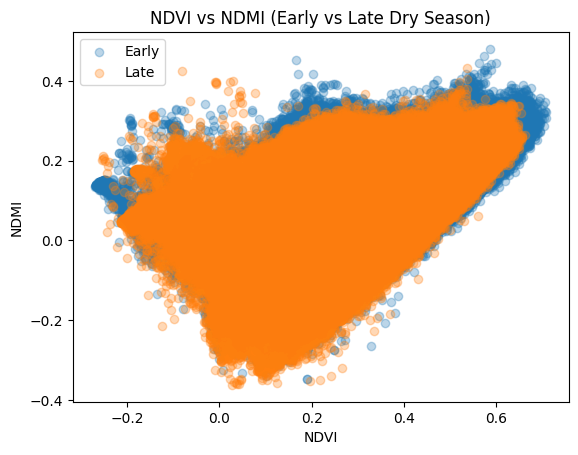

In [ ]:
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =======================
# 1. โหลด 2 ไฟล์
# =======================
file_early = "/content/drive/MyDrive/เลย/Loei_EarlyDry_2022.tif"
file_late  = "/content/drive/MyDrive/เลย/Loei_LateDry_2022.tif"

src_early = rasterio.open(file_early)
src_late  = rasterio.open(file_late)

# =======================
# 2. อ่าน band
# =======================
ndvi_early = src_early.read(1)
ndmi_early = src_early.read(2)

ndvi_late  = src_late.read(1)
ndmi_late  = src_late.read(2)

# =======================
# 3. flatten + clean
# =======================
def clean_data(a, b):
    a_flat = a.flatten()
    b_flat = b.flatten()
    mask = (~np.isnan(a_flat)) & (~np.isnan(b_flat))
    return a_flat[mask], b_flat[mask]

ndvi_e, ndmi_e = clean_data(ndvi_early, ndmi_early)
ndvi_l, ndmi_l = clean_data(ndvi_late, ndmi_late)

# =======================
# 4. DataFrame
# =======================
df_early = pd.DataFrame({'NDVI': ndvi_e, 'NDMI': ndmi_e})
df_late  = pd.DataFrame({'NDVI': ndvi_l, 'NDMI': ndmi_l})

# =======================
# 5. Correlation
# =======================
print("=== Early Dry Season ===")
print(df_early.corr())

print("\n=== Late Dry Season ===")
print(df_late.corr())

# =======================
# 6. Plot เปรียบเทียบ
# =======================
plt.figure()

plt.scatter(df_early['NDVI'], df_early['NDMI'], alpha=0.3, label='Early')
plt.scatter(df_late['NDVI'], df_late['NDMI'], alpha=0.3, label='Late')

plt.xlabel("NDVI")
plt.ylabel("NDMI")
plt.title("NDVI vs NDMI (Early vs Late Dry Season)")
plt.legend()

plt.show()